In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded!")

Libraries loaded!


In [2]:
#  Load city_day + stations
df = pd.read_csv("city_day.csv", parse_dates=["Date"])
stations = pd.read_csv("stations.csv")

df = df.sort_values(["City", "Date"]).reset_index(drop=True)

print("city_day shape :", df.shape)
print("stations shape :", stations.shape)
print("\nColumns in city_day:\n", list(df.columns))
df.head()

city_day shape : (29531, 16)
stations shape : (230, 5)

Columns in city_day:
 ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# Merge State info into city_day
# Get unique city → state mapping from stations
city_state = stations[["City", "State"]].drop_duplicates()

df = df.merge(city_state, on="City", how="left")

print("Cities with no state match:", df[df["State"].isna()]["City"].unique())
print("\nSample after merge:")
df[["City", "State", "Date", "AQI", "AQI_Bucket"]].head(8)

Cities with no state match: <ArrowStringArray>
[]
Length: 0, dtype: str

Sample after merge:


,City,State,Date,AQI,AQI_Bucket
0,Ahmedabad,Gujarat,2015-01-01,NaN,NaN
1,Ahmedabad,Gujarat,2015-01-02,NaN,NaN
2,Ahmedabad,Gujarat,2015-01-03,NaN,NaN
3,Ahmedabad,Gujarat,2015-01-04,NaN,NaN
4,Ahmedabad,Gujarat,2015-01-05,NaN,NaN
5,Ahmedabad,Gujarat,2015-01-06,NaN,NaN
6,Ahmedabad,Gujarat,2015-01-07,NaN,NaN
7,Ahmedabad,Gujarat,2015-01-08,NaN,NaN


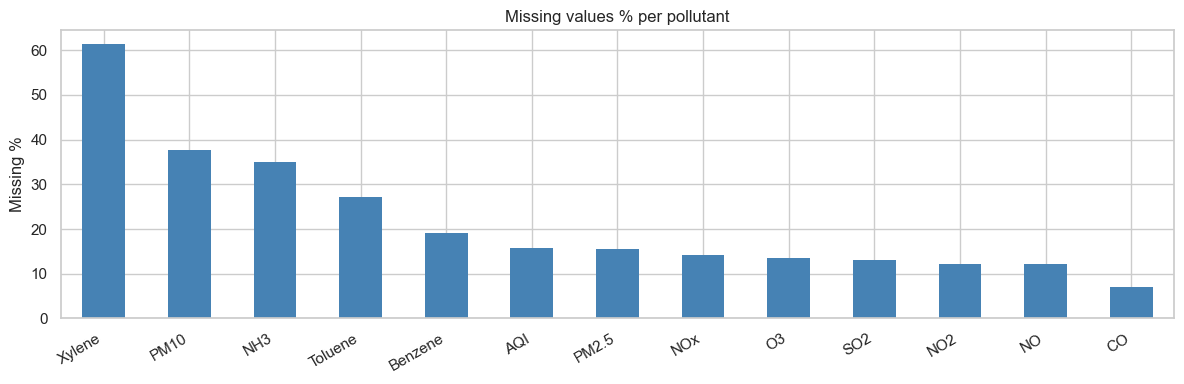

Xylene     61.32
PM10       37.72
NH3        34.97
Toluene    27.23
Benzene    19.04
AQI        15.85
PM2.5      15.57
NOx        14.17
O3         13.62
SO2        13.05
NO2        12.14
NO         12.13
CO          6.97
dtype: float64


In [4]:
# Missing values overview
pollutants = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene","Xylene","AQI"]

missing_pct = (df[pollutants].isnull().sum() / len(df) * 100).sort_values(ascending=False).round(2)

plt.figure(figsize=(12, 4))
missing_pct.plot(kind="bar", color="steelblue", edgecolor="none")
plt.title("Missing values % per pollutant")
plt.ylabel("Missing %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(missing_pct)

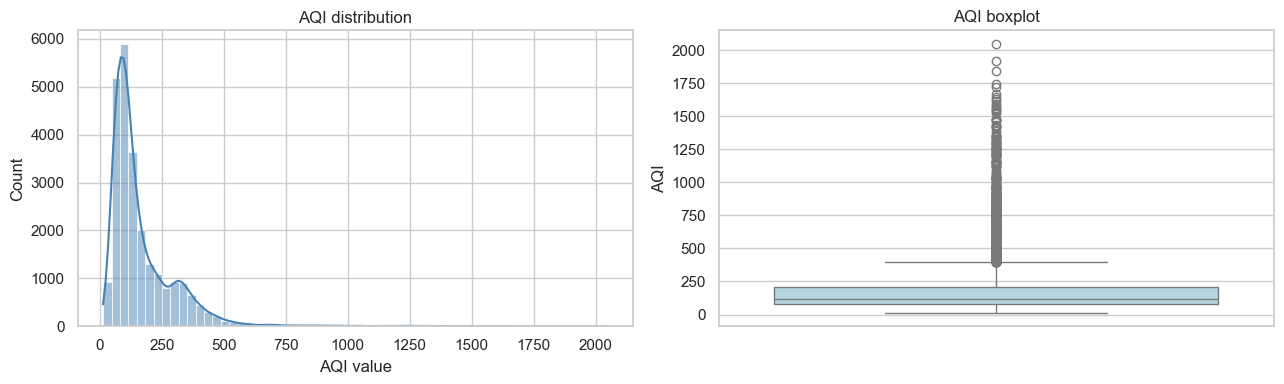

count    24850.00
mean       166.46
std        140.70
min         13.00
25%         81.00
50%        118.00
75%        208.00
max       2049.00
Name: AQI, dtype: float64


In [5]:
# AQI distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["AQI"].dropna(), bins=60, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("AQI distribution")
axes[0].set_xlabel("AQI value")

sns.boxplot(y=df["AQI"].dropna(), color="lightblue", ax=axes[1])
axes[1].set_title("AQI boxplot")

plt.tight_layout()
plt.show()

print(df["AQI"].describe().round(2))

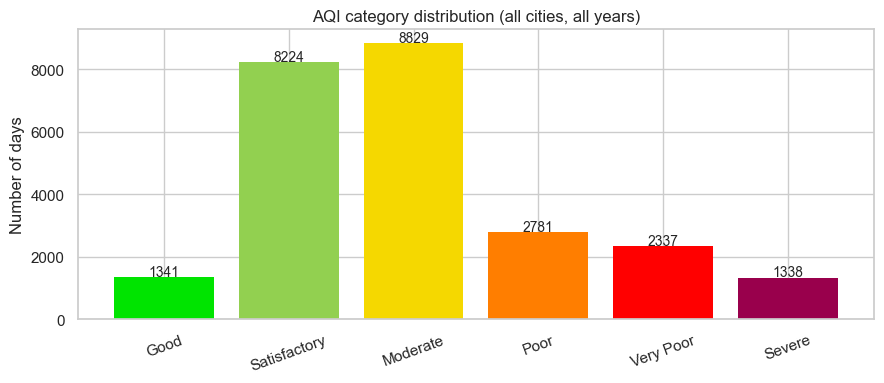

In [6]:
# AQI category breakdown
cat_order  = ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]
cat_colors = ["#00e400","#92d050","#f5d800","#ff7e00","#ff0000","#99004c"]

cat_counts = df["AQI_Bucket"].value_counts().reindex(cat_order)

plt.figure(figsize=(9, 4))
bars = plt.bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor="none")
plt.title("AQI category distribution (all cities, all years)")
plt.ylabel("Number of days")
plt.xticks(rotation=20)

for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

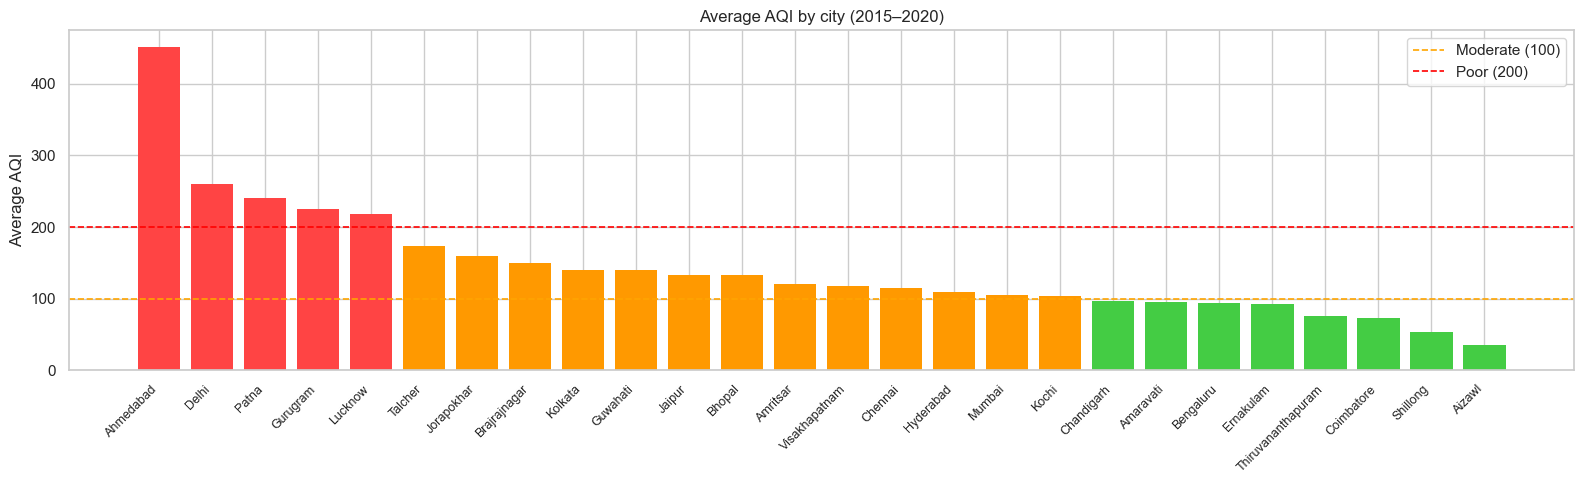

Top 5 most polluted:
         City     Avg_AQI
0  Ahmedabad  452.122939
1      Delhi  259.487744
2      Patna  240.782042
3   Gurugram  225.123882
4    Lucknow  217.973059

Top 5 cleanest:
                   City    Avg_AQI
21           Ernakulam  92.359477
22  Thiruvananthapuram  75.878327
23          Coimbatore  73.023256
24            Shillong  53.795122
25              Aizawl  34.765766


In [7]:
# Average AQI by city (bar chart)
city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False).reset_index()
city_aqi.columns = ["City", "Avg_AQI"]

plt.figure(figsize=(16, 5))
colors = ["#ff4444" if v > 200 else "#ff9900" if v > 100 else "#44cc44"
          for v in city_aqi["Avg_AQI"]]
plt.bar(city_aqi["City"], city_aqi["Avg_AQI"], color=colors, edgecolor="none")
plt.axhline(100, color="orange", linestyle="--", linewidth=1.2, label="Moderate (100)")
plt.axhline(200, color="red",    linestyle="--", linewidth=1.2, label="Poor (200)")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Average AQI by city (2015–2020)")
plt.ylabel("Average AQI")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 most polluted:\n", city_aqi.head())
print("\nTop 5 cleanest:\n", city_aqi.tail())

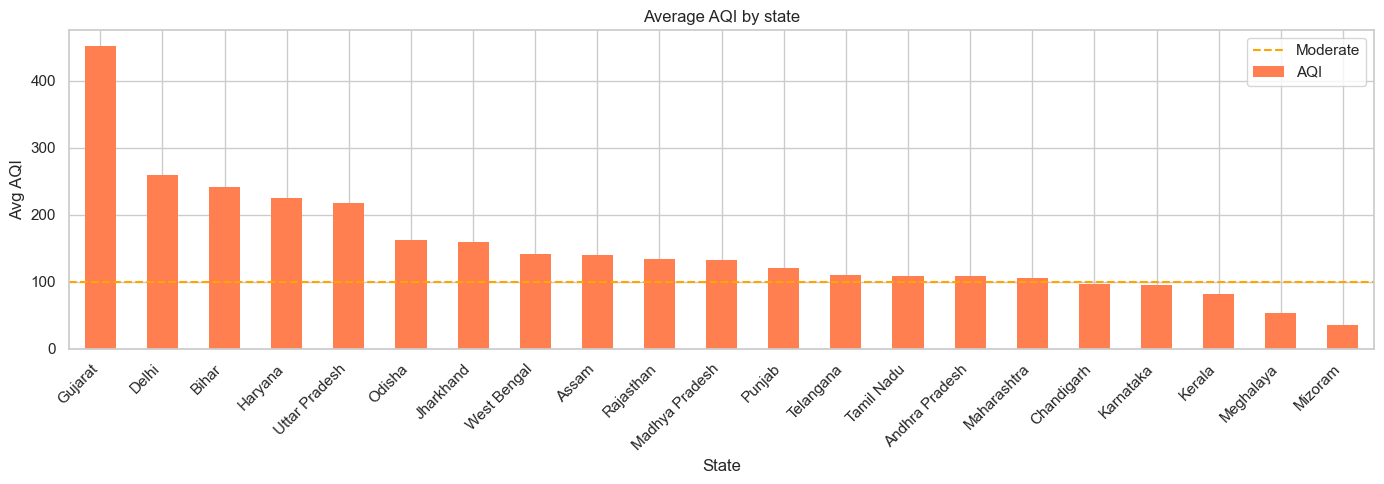

In [ ]:
# AQI by state (bar chart)
state_aqi = df.groupby("State")["AQI"].mean().sort_values(ascending=False).dropna()

plt.figure(figsize=(14, 5))
state_aqi.plot(kind="bar", color="coral", edgecolor="none")
plt.title("Average AQI by state")
plt.ylabel("Avg AQI")
plt.xticks(rotation=45, ha="right")
plt.axhline(100, color="orange", linestyle="--", label="Moderate")
plt.legend()
plt.tight_layout()
plt.show()

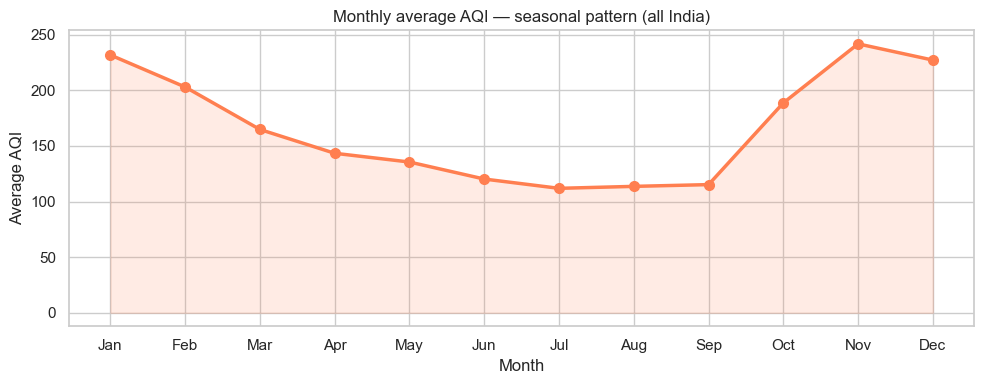

Worst month: Nov
Best month : Jul


In [9]:
#  Seasonal monthly pattern
df["month"] = df["Date"].dt.month
df["year"]  = df["Date"].dt.year
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly = df.groupby("month")["AQI"].mean().reset_index()
monthly["month_name"] = month_names

plt.figure(figsize=(10, 4))
plt.plot(monthly["month_name"], monthly["AQI"], marker="o", color="coral",
         linewidth=2.5, markersize=7)
plt.fill_between(monthly["month_name"], monthly["AQI"], alpha=0.15, color="coral")
plt.title("Monthly average AQI — seasonal pattern (all India)")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

print("Worst month:", monthly.loc[monthly["AQI"].idxmax(), "month_name"])
print("Best month :", monthly.loc[monthly["AQI"].idxmin(), "month_name"])

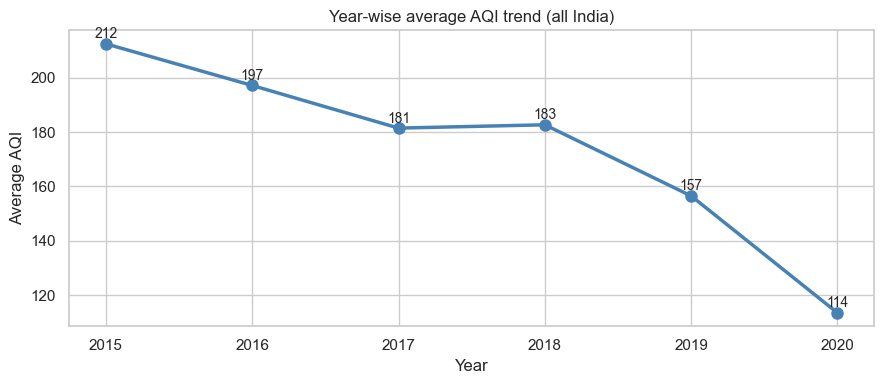

In [11]:
#  Year-wise AQI trend
yearly = df.groupby("year")["AQI"].mean().reset_index()

plt.figure(figsize=(9, 4))
plt.plot(yearly["year"], yearly["AQI"], marker="o", color="steelblue",
         linewidth=2.5, markersize=8)
for _, row in yearly.iterrows():
    plt.text(row["year"], row["AQI"] + 2, f"{row['AQI']:.0f}", ha="center", fontsize=10)
plt.title("Year-wise average AQI trend (all India)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

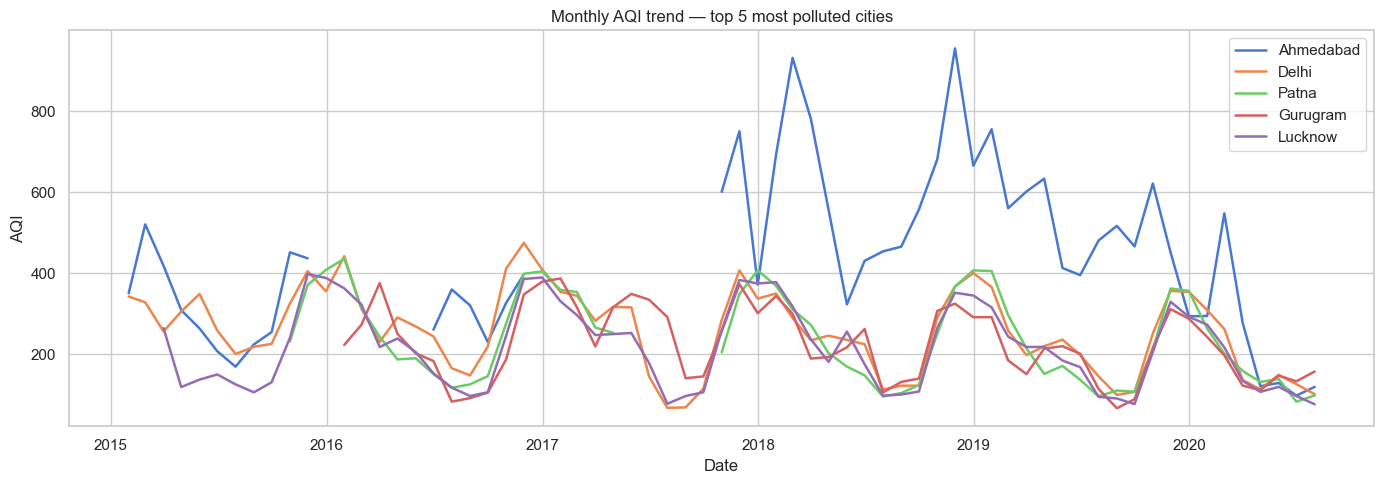

In [12]:
#  Top 5 cities AQI trend over time
top5 = city_aqi.head(5)["City"].tolist()
top5_df = df[df["City"].isin(top5)].copy()

top5_monthly = (
    top5_df.groupby(["City", pd.Grouper(key="Date", freq="ME")])["AQI"]
    .mean().reset_index()
)

plt.figure(figsize=(14, 5))
for city in top5:
    sub = top5_monthly[top5_monthly["City"] == city]
    plt.plot(sub["Date"], sub["AQI"], label=city, linewidth=1.8)

plt.title("Monthly AQI trend — top 5 most polluted cities")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

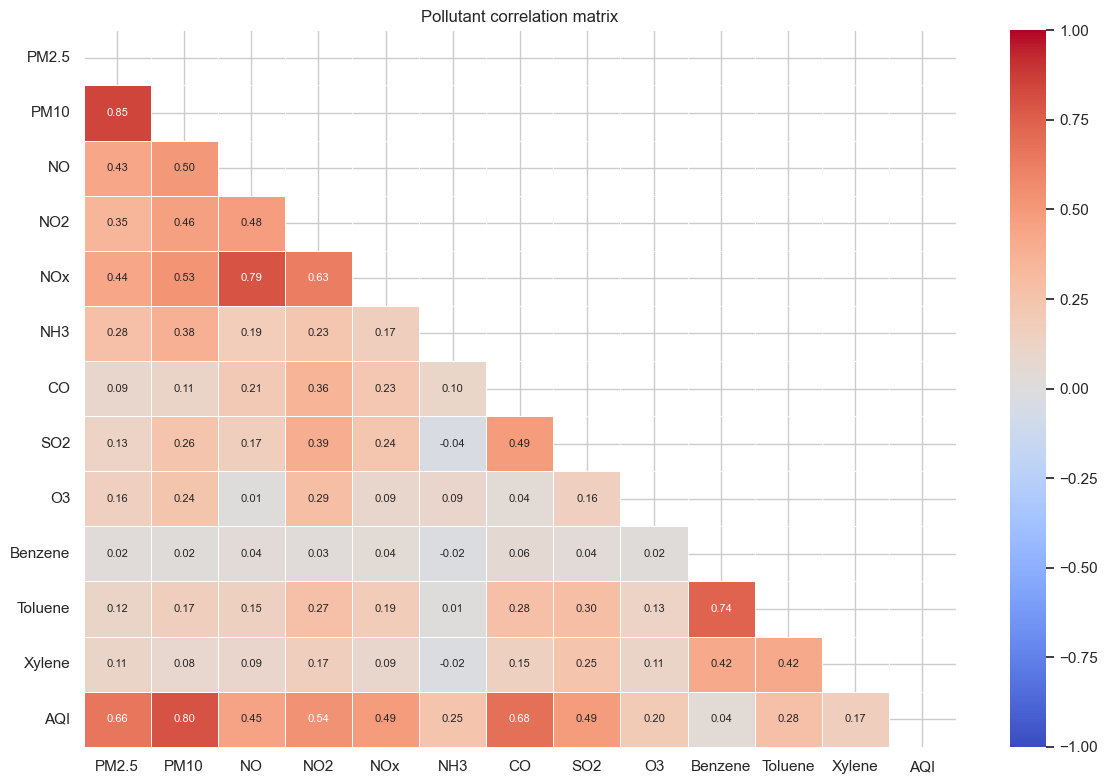

In [13]:
#  Pollutant correlation heatmap
corr = df[pollutants].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("Pollutant correlation matrix")
plt.tight_layout()
plt.show()

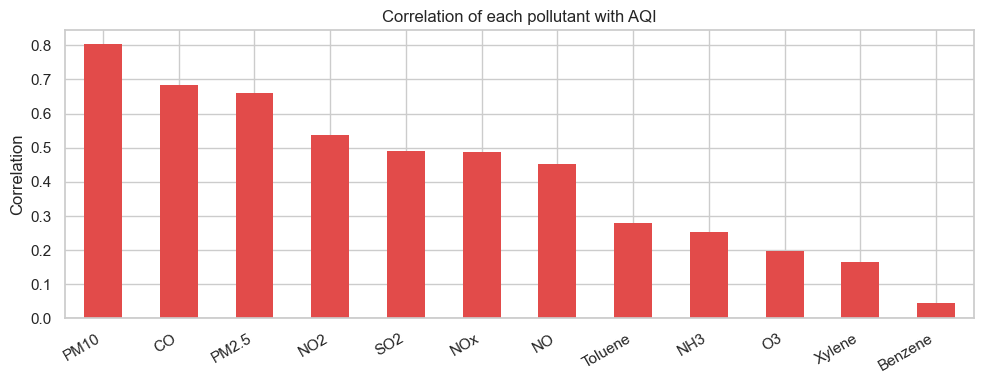

PM10       0.803
CO         0.683
PM2.5      0.659
NO2        0.537
SO2        0.491
NOx        0.486
NO         0.452
Toluene    0.280
NH3        0.252
O3         0.199
Xylene     0.166
Benzene    0.044
Name: AQI, dtype: float64


In [14]:
# Which pollutants drive AQI the most?
corr_aqi = df[pollutants].corr()["AQI"].drop("AQI").sort_values(ascending=False)

plt.figure(figsize=(10, 4))
colors = ["#E24B4A" if v > 0 else "#378ADD" for v in corr_aqi]
corr_aqi.plot(kind="bar", color=colors, edgecolor="none")
plt.title("Correlation of each pollutant with AQI")
plt.ylabel("Correlation")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(corr_aqi.round(3))